In [2]:
import random
import csv

# Number of students
num_students = 500

with open("student_curriculum_dataset.csv", "w", newline="") as file:
    writer = csv.writer(file)

    # Header
    header = [
        "Student_ID",
        "Academic_Score",
        "Industry_Skill",
        "Skill_Gap",
        "Employability_Percentage",
        "Employment_Status"
    ]

    writer.writerow(header)

    # Print header
    print("{:<10} {:<10} {:<15} {:<10} {:<15} {}".format(
        "Student", "Academic", "Industry", "Gap", "Employability", "Status"
    ))

    for i in range(1, num_students + 1):

        academic = random.randint(40, 100)
        industry = random.randint(30, 100)

        gap = abs(academic - industry)

        employability = 100 - gap

        if academic >= 80 and industry >= 80:
            employability += 10

        if industry < 50:
            employability -= 10

        employability += random.randint(-5, 5)
        employability = max(0, min(100, employability))

        status = "Employed" if employability >= 70 else "Not Employed"

        row = [
            f"S{i:03}",
            academic,
            industry,
            gap,
            employability,
            status
        ]

        # Save to CSV
        writer.writerow(row)

        # Print on console
        print("{:<10} {:<10} {:<15} {:<10} {:<15} {}".format(
            row[0], row[1], row[2], row[3], row[4], row[5]
        ))

print("\nDataset with 500 records generated successfully!")
print("File saved as: student_curriculum_dataset.csv")

Student    Academic   Industry        Gap        Employability   Status
S001       59         44              15         73              Employed
S002       50         67              17         87              Employed
S003       46         81              35         67              Not Employed
S004       55         68              13         85              Employed
S005       92         93              1          100             Employed
S006       53         59              6          92              Employed
S007       92         56              36         61              Not Employed
S008       88         49              39         54              Not Employed
S009       98         84              14         93              Employed
S010       64         50              14         91              Employed
S011       67         35              32         62              Not Employed
S012       84         55              29         70              Employed
S013       44         73

### Load Dataset and Initial Preprocessing

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('student_curriculum_dataset.csv')

# Display the first 5 rows and information about the dataframe
print("Dataset Head:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nDataset Description:")
display(df.describe())

Dataset Head:


,Student_ID,Academic_Score,Industry_Skill,Skill_Gap,Employability_Percentage,Employment_Status
0,S001,59,44,15,73,Employed
1,S002,50,67,17,87,Employed
2,S003,46,81,35,67,Not Employed
3,S004,55,68,13,85,Employed
4,S005,92,93,1,100,Employed



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Student_ID                500 non-null    object
 1   Academic_Score            500 non-null    int64 
 2   Industry_Skill            500 non-null    int64 
 3   Skill_Gap                 500 non-null    int64 
 4   Employability_Percentage  500 non-null    int64 
 5   Employment_Status         500 non-null    object
dtypes: int64(4), object(2)
memory usage: 23.6+ KB

Dataset Description:


,Academic_Score,Industry_Skill,Skill_Gap,Employability_Percentage
count,500.000000,500.000000,500.000000,500.000000
mean,70.010000,65.652000,22.446000,75.336000
std,17.258087,20.918462,15.481811,18.611929
min,40.000000,30.000000,0.000000,17.000000
25%,56.000000,48.000000,9.000000,62.000000
50%,70.000000,65.500000,20.500000,78.000000
75%,85.000000,85.000000,33.000000,91.000000
max,100.000000,100.000000,70.000000,100.000000


### Feature Engineering and Data Splitting

- Convert `Employment_Status` to a numerical format.
- Define features (X) and target (y).
- Split the data into training and testing sets.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Convert 'Employment_Status' to numerical (0 for 'Not Employed', 1 for 'Employed')
le = LabelEncoder()
df['Employment_Status_Encoded'] = le.fit_transform(df['Employment_Status'])

# Define features (X) and target (y)
# Removed 'Employability_Percentage' due to potential data leakage
X = df[['Academic_Score', 'Industry_Skill', 'Skill_Gap']]
y = df['Employment_Status_Encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTarget distribution in training set:")
display(y_train.value_counts(normalize=True))
print("\nTarget distribution in test set:")
display(y_test.value_counts(normalize=True))

X_train shape: (350, 3)
X_test shape: (150, 3)
y_train shape: (350,)
y_test shape: (150,)

Target distribution in training set:


,proportion
Employment_Status_Encoded,
0,0.642857
1,0.357143



Target distribution in test set:


,proportion
Employment_Status_Encoded,
0,0.646667
1,0.353333


### Model Training

In [5]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


### Model Evaluation

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


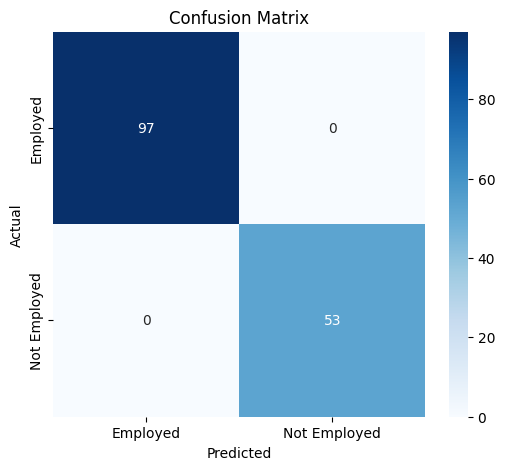

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()